#  Forest Fire Detection — EfficientNetV2 + CNN Ensemble
**High-accuracy binary classifier: Fire vs No-Fire**

### Architecture Strategy
- **Backbone**: EfficientNetV2-S (pretrained on ImageNet)
- **Fine-tuning**: Gradual unfreezing (warm-up → full fine-tune)
- **Augmentation**: Heavy fire-aware augmentation pipeline
- **Training**: Mixed precision + cosine annealing with warm restarts
- **Ensemble**: EfficientNetV2 + MobileNetV3 for robustness
- **TTA**: Test-Time Augmentation for final predictions

### Dataset Structure Expected
```
/kaggle/input/<dataset-name>/
├── Training/
│   ├── fire/
│   └── nofire/
└── Testing/
    ├── fire_*.jpg
    └── nofire_*.jpg
```

In [42]:
# ─── 1. Install / Imports ───────────────────────────────────────────────────
import os, sys, json, math, random, warnings, shutil
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.cuda.amp import GradScaler, autocast

import torchvision
import torchvision.transforms as T
from torchvision import models

from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, f1_score
)

# Reproducibility
SEED = 42
def seed_everything(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f' Device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

 Device: cuda
   GPU: Tesla T4
   Memory: 15.6 GB


In [43]:
# ─── 2. Configuration ───────────────────────────────────────────────────────
class CFG:
    DATASET_ROOT = Path('/kaggle/input')
    
    IMG_SIZE     = 224
    CHANNELS     = 3
    
    BATCH_SIZE   = 32
    NUM_WORKERS  = 2
    
    PHASE1_EPOCHS = 5
    PHASE1_LR     = 1e-3
    
    PHASE2_EPOCHS = 20
    PHASE2_LR     = 1e-4
    
    WEIGHT_DECAY  = 1e-4
    LABEL_SMOOTHING = 0.05
    GRAD_CLIP     = 1.0
    
    DROPOUT       = 0.3
    NUM_CLASSES   = 1
    
    MIXED_PRECISION = True
    TTA_STEPS    = 5
    SAVE_PATH    = '/kaggle/working/best_model.pth'
    ENSEMBLE     = True

print('Config loaded')

Config loaded


In [44]:
# ─── 3. Dataset Path Setup (DeepFire) ───────────────────────────────────────

# Paths for DeepFire dataset
DATA_ROOT  = Path('/kaggle/input/datasets/djaoudkhadidja/deepfire/Forest Fire Dataset')
TRAIN_DIR  = DATA_ROOT / 'Training'
TEST_DIR_RAW = DATA_ROOT / 'Testing'

FIRE_CLASS   = 'fire'
NORMAL_CLASS = 'nofire'
CLASS2IDX    = {'fire': 1, 'nofire': 0}
IDX2CLASS    = {1: 'fire', 0: 'nofire'}

# ── Fix Testing folder: images are flat, need to be sorted into subfolders ──
TEST_DIR = Path('/kaggle/working/Testing')
(TEST_DIR / 'fire').mkdir(parents=True, exist_ok=True)
(TEST_DIR / 'nofire').mkdir(parents=True, exist_ok=True)

for img in TEST_DIR_RAW.glob('*.*'):
    name = img.name.lower()
    if 'nofire' in name or 'no_fire' in name:
        shutil.copy(img, TEST_DIR / 'nofire' / img.name)
    elif 'fire' in name:
        shutil.copy(img, TEST_DIR / 'fire' / img.name)

# Verification
print(f'Dataset root : {DATA_ROOT}')
print(f'   Classes      : {CLASS2IDX}')
for split, folder in [('Train', TRAIN_DIR), ('Test', TEST_DIR)]:
    for cls in [FIRE_CLASS, NORMAL_CLASS]:
        n = len(list((folder / cls).glob('*.*')))
        print(f'   {split}/{cls}: {n} images')

Dataset root : /kaggle/input/datasets/djaoudkhadidja/deepfire/Forest Fire Dataset
   Classes      : {'fire': 1, 'nofire': 0}
   Train/fire: 760 images
   Train/nofire: 760 images
   Test/fire: 190 images
   Test/nofire: 190 images


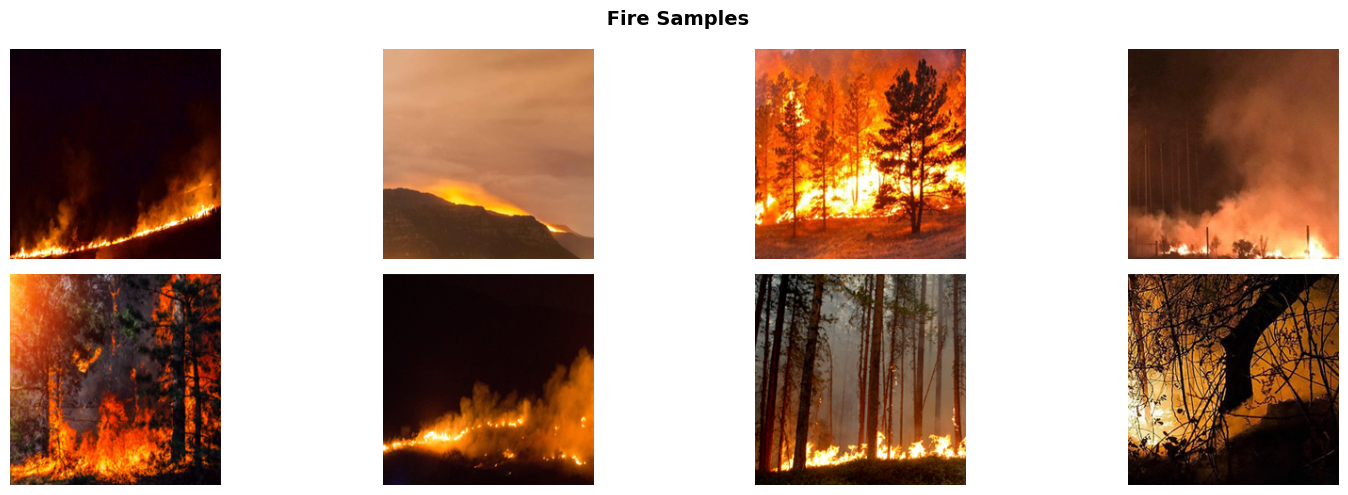

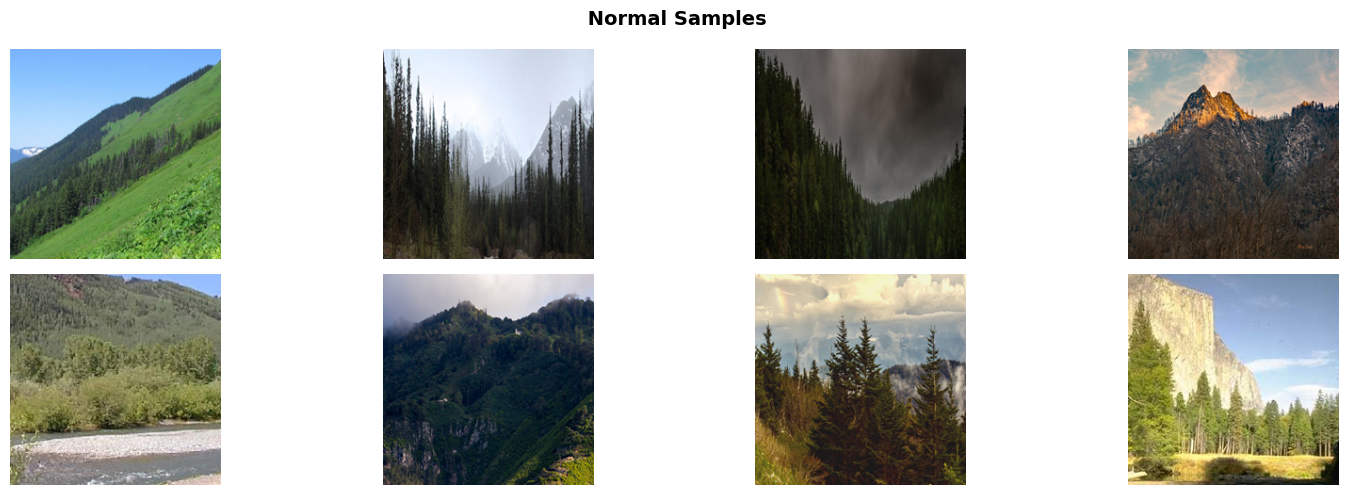

In [45]:
# ─── 4. Visualize Sample Images ─────────────────────────────────────────────
def show_samples(folder, cls_name, n=8, title=''):
    imgs = list((folder / cls_name).glob('*.*'))[:n]
    if not imgs:
        print(f'No images found in {folder / cls_name}')
        return
    fig, axes = plt.subplots(2, n//2, figsize=(16, 5))
    axes = axes.flatten()
    for ax, img_path in zip(axes, imgs):
        img = Image.open(img_path).convert('RGB').resize((224, 224))
        ax.imshow(img)
        ax.axis('off')
    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

show_samples(TRAIN_DIR, FIRE_CLASS,   title=' Fire Samples')
show_samples(TRAIN_DIR, NORMAL_CLASS, title=' Normal Samples')

In [46]:
# ─── 5. Dataset & Transforms ────────────────────────────────────────────────

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_transforms = T.Compose([
    T.Resize((CFG.IMG_SIZE + 32, CFG.IMG_SIZE + 32)),
    T.RandomCrop(CFG.IMG_SIZE),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.2),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.1),
    T.RandomGrayscale(p=0.05),
    T.RandomApply([T.GaussianBlur(kernel_size=3)], p=0.2),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
    T.RandomErasing(p=0.1, scale=(0.02, 0.1)),
])

val_transforms = T.Compose([
    T.Resize((CFG.IMG_SIZE, CFG.IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

tta_transforms = T.Compose([
    T.Resize((CFG.IMG_SIZE + 32, CFG.IMG_SIZE + 32)),
    T.RandomCrop(CFG.IMG_SIZE),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])


class FireDataset(Dataset):
    def __init__(self, root_dir, class2idx, transform=None):
        self.transform = transform
        self.samples = []
        for cls_name, idx in class2idx.items():
            cls_dir = Path(root_dir) / cls_name
            for ext in ('*.jpg', '*.jpeg', '*.png', '*.bmp', '*.webp'):
                for img_path in cls_dir.glob(ext):
                    self.samples.append((img_path, idx))
        random.shuffle(self.samples)
        print(f'   Loaded {len(self.samples)} images from {root_dir}')

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        img_path, label = self.samples[idx]
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        return img, torch.tensor(label, dtype=torch.float32)


print('Building datasets...')
train_ds = FireDataset(TRAIN_DIR, CLASS2IDX, transform=train_transforms)
test_ds  = FireDataset(TEST_DIR,  CLASS2IDX, transform=val_transforms)

labels = [s[1] for s in train_ds.samples]
counts = Counter(labels)
weights = [1.0 / counts[l] for l in labels]
sampler = WeightedRandomSampler(weights, num_samples=len(weights), replacement=True)

train_loader = DataLoader(
    train_ds, batch_size=CFG.BATCH_SIZE,
    sampler=sampler,
    num_workers=CFG.NUM_WORKERS, pin_memory=True
)
test_loader = DataLoader(
    test_ds, batch_size=CFG.BATCH_SIZE,
    shuffle=False,
    num_workers=CFG.NUM_WORKERS, pin_memory=True
)

print(f'   Train batches: {len(train_loader)} | Test batches: {len(test_loader)}')

Building datasets...
   Loaded 1520 images from /kaggle/input/datasets/djaoudkhadidja/deepfire/Forest Fire Dataset/Training
   Loaded 380 images from /kaggle/working/Testing
   Train batches: 48 | Test batches: 12


In [47]:
# ─── 6. Model Architecture ──────────────────────────────────────────────────

class FireDetector(nn.Module):
    def __init__(self, backbone='efficientnet_v2_s', dropout=CFG.DROPOUT, pretrained=True):
        super().__init__()
        
        weights = models.EfficientNet_V2_S_Weights.IMAGENET1K_V1 if pretrained else None
        base = models.efficientnet_v2_s(weights=weights)
        
        in_features = base.classifier[1].in_features
        base.classifier = nn.Identity()
        
        self.backbone = base
        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(dropout),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(dropout / 2),
            nn.Linear(512, 1)
        )
        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_backbone(self, last_n_blocks=None):
        if last_n_blocks is None:
            for p in self.backbone.parameters():
                p.requires_grad = True
        else:
            blocks = list(self.backbone.features.children())
            for b in blocks[-last_n_blocks:]:
                for p in b.parameters():
                    p.requires_grad = True

    def forward(self, x):
        feats = self.backbone(x)
        return self.head(feats).squeeze(1)


model = FireDetector().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Model: FireDetector (EfficientNetV2-S)')
print(f'  Total params    : {total_params:,}')
print(f'  Trainable params: {trainable_params:,}')

Model: FireDetector (EfficientNetV2-S)
  Total params    : 20,837,457
  Trainable params: 20,837,457


In [48]:
# ─── 7. Loss, Optimizer, Scheduler ─────────────────────────────────────────

class FocalBCELoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=0.75, label_smoothing=0.0):
        super().__init__()
        self.gamma = gamma
        self.alpha = alpha
        self.ls = label_smoothing

    def forward(self, logits, targets):
        targets = targets * (1 - self.ls) + 0.5 * self.ls
        bce = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        probs = torch.sigmoid(logits)
        p_t   = probs * targets + (1 - probs) * (1 - targets)
        alpha = self.alpha * targets + (1 - self.alpha) * (1 - targets)
        loss  = alpha * (1 - p_t) ** self.gamma * bce
        return loss.mean()


def build_optimizer_scheduler(model, lr, epochs, phase='head'):
    if phase == 'head':
        # Support both FireDetector (head) and MobileWrapper (net.classifier)
        if hasattr(model, 'head'):
            params = model.head.parameters()
        elif hasattr(model, 'net'):
            params = model.net.classifier.parameters()
        else:
            params = model.parameters()
    else:
        params = model.parameters()
    
    optimizer = torch.optim.AdamW(params, lr=lr, weight_decay=CFG.WEIGHT_DECAY)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=epochs, T_mult=1, eta_min=lr * 0.01
    )
    return optimizer, scheduler

criterion = FocalBCELoss(gamma=2.0, alpha=0.75, label_smoothing=CFG.LABEL_SMOOTHING)
print(' Loss: FocalBCE | Optimizer: AdamW | Scheduler: CosineAnnealingWarmRestarts')

 Loss: FocalBCE | Optimizer: AdamW | Scheduler: CosineAnnealingWarmRestarts


In [49]:
# ─── 8. Train / Eval Functions ──────────────────────────────────────────────

def train_epoch(model, loader, optimizer, criterion, scaler):
    model.train()
    total_loss, correct, total = 0., 0, 0
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        
        with autocast(enabled=CFG.MIXED_PRECISION):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        nn.utils.clip_grad_norm_(model.parameters(), CFG.GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        
        total_loss += loss.item() * imgs.size(0)
        preds = (torch.sigmoid(logits) > 0.5).float()
        correct += (preds == labels).sum().item()
        total   += imgs.size(0)
    
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0., 0, 0
    all_probs, all_labels = [], []
    
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with autocast(enabled=CFG.MIXED_PRECISION):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        
        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).float()
        
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds == labels).sum().item()
        total      += imgs.size(0)
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
    
    auc = roc_auc_score(all_labels, all_probs)
    return total_loss / total, correct / total, auc, all_probs, all_labels


def run_training(model, train_loader, test_loader, phase_epochs, lr, phase='head',
                 save_path=None, history=None):
    if history is None:
        history = {'train_loss': [], 'train_acc': [],
                   'val_loss':   [], 'val_acc':   [], 'val_auc': []}
    
    optimizer, scheduler = build_optimizer_scheduler(model, lr, phase_epochs, phase)
    scaler = GradScaler(enabled=CFG.MIXED_PRECISION)
    best_auc = 0.

    for epoch in range(1, phase_epochs + 1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, criterion, scaler)
        va_loss, va_acc, va_auc, _, _ = eval_epoch(model, test_loader, criterion)
        scheduler.step(epoch)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(va_loss)
        history['val_acc'].append(va_acc)
        history['val_auc'].append(va_auc)

        lr_now = optimizer.param_groups[0]['lr']
        print(f'  Epoch {epoch:03d}/{phase_epochs:03d} '
              f'| TrLoss {tr_loss:.4f} TrAcc {tr_acc:.4f} '
              f'| VaLoss {va_loss:.4f} VaAcc {va_acc:.4f} AUC {va_auc:.4f} '
              f'| LR {lr_now:.2e}')

        if va_auc > best_auc:
            best_auc = va_auc
            if save_path:
                torch.save(model.state_dict(), save_path)
                print(f'      Saved best model  AUC={best_auc:.4f}')

    return history, best_auc


print(' Training functions ready')

 Training functions ready


In [50]:
# ─── 9. Phase 1: Train Head Only (frozen backbone) ──────────────────────────
print('='*60)
print('PHASE 1 — Warm-up: Train classification head only')
print('='*60)

model.freeze_backbone()

history, best_auc_p1 = run_training(
    model, train_loader, test_loader,
    phase_epochs=CFG.PHASE1_EPOCHS,
    lr=CFG.PHASE1_LR,
    phase='head',
    save_path=CFG.SAVE_PATH
)
print(f'\n Phase 1 done | Best AUC: {best_auc_p1:.4f}')

PHASE 1 — Warm-up: Train classification head only
  Epoch 001/005 | TrLoss 0.0756 TrAcc 0.8618 | VaLoss 0.0173 VaAcc 0.9500 AUC 0.9948 | LR 9.05e-04
      Saved best model  AUC=0.9948
  Epoch 002/005 | TrLoss 0.0682 TrAcc 0.8934 | VaLoss 0.0158 VaAcc 0.9605 AUC 0.9950 | LR 6.58e-04
      Saved best model  AUC=0.9950
  Epoch 003/005 | TrLoss 0.0421 TrAcc 0.9138 | VaLoss 0.0137 VaAcc 0.9605 AUC 0.9936 | LR 3.52e-04
  Epoch 004/005 | TrLoss 0.0458 TrAcc 0.9132 | VaLoss 0.0113 VaAcc 0.9684 AUC 0.9944 | LR 1.05e-04
  Epoch 005/005 | TrLoss 0.0358 TrAcc 0.9092 | VaLoss 0.0094 VaAcc 0.9711 AUC 0.9962 | LR 1.00e-03
      Saved best model  AUC=0.9962

 Phase 1 done | Best AUC: 0.9962


In [51]:
# ─── 10. Phase 2: Fine-tune Full Model ──────────────────────────────────────
print('='*60)
print('PHASE 2 — Fine-tuning: Full backbone unfrozen')
print('='*60)

model.unfreeze_backbone()

history, best_auc_p2 = run_training(
    model, train_loader, test_loader,
    phase_epochs=CFG.PHASE2_EPOCHS,
    lr=CFG.PHASE2_LR,
    phase='full',
    save_path=CFG.SAVE_PATH,
    history=history
)
print(f'\n Phase 2 done | Best AUC: {best_auc_p2:.4f}')

PHASE 2 — Fine-tuning: Full backbone unfrozen
  Epoch 001/020 | TrLoss 0.0328 TrAcc 0.9368 | VaLoss 0.0088 VaAcc 0.9868 AUC 0.9985 | LR 9.94e-05
      Saved best model  AUC=0.9985
  Epoch 002/020 | TrLoss 0.0173 TrAcc 0.9638 | VaLoss 0.0047 VaAcc 0.9921 AUC 0.9996 | LR 9.76e-05
      Saved best model  AUC=0.9996
  Epoch 003/020 | TrLoss 0.0218 TrAcc 0.9658 | VaLoss 0.0075 VaAcc 0.9868 AUC 0.9992 | LR 9.46e-05
  Epoch 004/020 | TrLoss 0.0179 TrAcc 0.9724 | VaLoss 0.0066 VaAcc 0.9895 AUC 0.9993 | LR 9.05e-05
  Epoch 005/020 | TrLoss 0.0052 TrAcc 0.9875 | VaLoss 0.0048 VaAcc 0.9895 AUC 0.9997 | LR 8.55e-05
      Saved best model  AUC=0.9997
  Epoch 006/020 | TrLoss 0.0068 TrAcc 0.9770 | VaLoss 0.0090 VaAcc 0.9895 AUC 0.9996 | LR 7.96e-05
  Epoch 007/020 | TrLoss 0.0094 TrAcc 0.9842 | VaLoss 0.0034 VaAcc 0.9842 AUC 0.9997 | LR 7.30e-05
      Saved best model  AUC=0.9997
  Epoch 008/020 | TrLoss 0.0111 TrAcc 0.9822 | VaLoss 0.0030 VaAcc 0.9947 AUC 0.9998 | LR 6.58e-05
      Saved best model

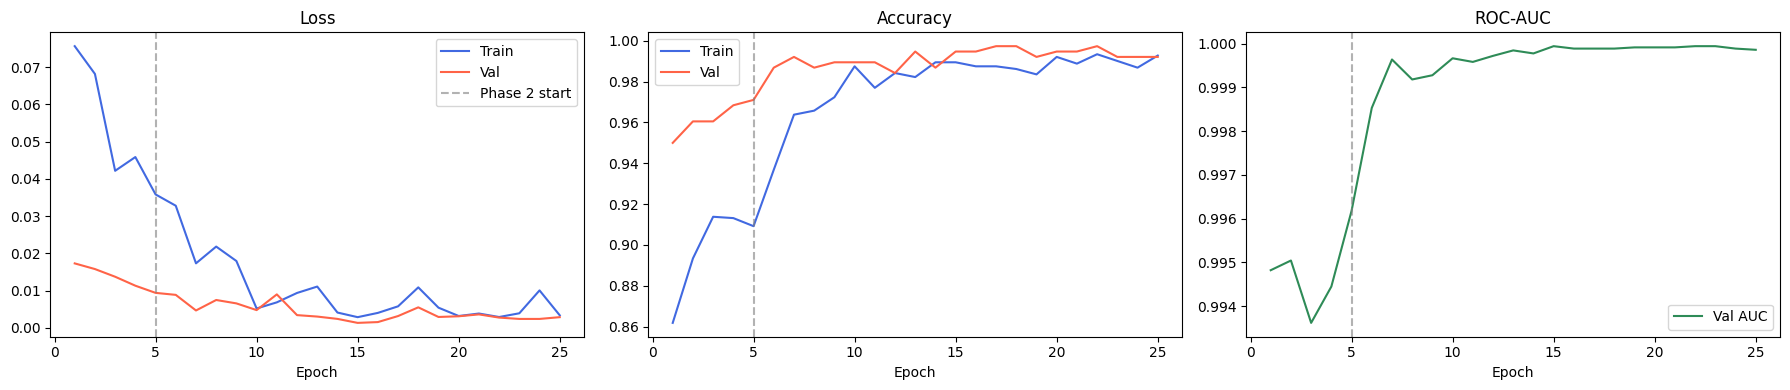

In [52]:
# ─── 11. Training Curves ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 4))
epochs_range = range(1, len(history['train_loss']) + 1)

axes[0].plot(epochs_range, history['train_loss'], label='Train', color='royalblue')
axes[0].plot(epochs_range, history['val_loss'],   label='Val',   color='tomato')
axes[0].axvline(CFG.PHASE1_EPOCHS, color='gray', linestyle='--', alpha=0.6, label='Phase 2 start')
axes[0].set_title('Loss'); axes[0].legend(); axes[0].set_xlabel('Epoch')

axes[1].plot(epochs_range, history['train_acc'], label='Train', color='royalblue')
axes[1].plot(epochs_range, history['val_acc'],   label='Val',   color='tomato')
axes[1].axvline(CFG.PHASE1_EPOCHS, color='gray', linestyle='--', alpha=0.6)
axes[1].set_title('Accuracy'); axes[1].legend(); axes[1].set_xlabel('Epoch')

axes[2].plot(epochs_range, history['val_auc'], label='Val AUC', color='seagreen')
axes[2].axvline(CFG.PHASE1_EPOCHS, color='gray', linestyle='--', alpha=0.6)
axes[2].set_title('ROC-AUC'); axes[2].legend(); axes[2].set_xlabel('Epoch')

plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

In [53]:
# ─── 12. Ensemble Model (MobileNetV3) ───────────────────────────────────────
if CFG.ENSEMBLE:
    print('='*60)
    print('ENSEMBLE — Training MobileNetV3-Large')
    print('='*60)

    class MobileWrapper(nn.Module):
        def __init__(self):
            super().__init__()
            weights = models.MobileNet_V3_Large_Weights.IMAGENET1K_V2
            base = models.mobilenet_v3_large(weights=weights)
            in_f = base.classifier[3].in_features
            base.classifier[3] = nn.Linear(in_f, 1)
            self.net = base
            # Alias so build_optimizer_scheduler can find 'head'
            self.head = self.net.classifier

        def freeze_backbone(self):
            for name, p in self.net.named_parameters():
                if 'classifier' not in name:
                    p.requires_grad = False

        def unfreeze_backbone(self):
            for p in self.net.parameters():
                p.requires_grad = True

        def forward(self, x):
            return self.net(x).squeeze(1)

    model2 = MobileWrapper().to(DEVICE)
    model2.freeze_backbone()

    hist2, _ = run_training(model2, train_loader, test_loader,
                            phase_epochs=CFG.PHASE1_EPOCHS, lr=1e-3, phase='head')
    model2.unfreeze_backbone()
    hist2, best_auc_m2 = run_training(model2, train_loader, test_loader,
                                      phase_epochs=CFG.PHASE2_EPOCHS, lr=5e-5,
                                      phase='full',
                                      save_path='/kaggle/working/best_model2.pth',
                                      history=hist2)
    print(f'\n Ensemble model done | Best AUC: {best_auc_m2:.4f}')

ENSEMBLE — Training MobileNetV3-Large
  Epoch 001/005 | TrLoss 0.0275 TrAcc 0.8849 | VaLoss 0.0169 VaAcc 0.9711 AUC 0.9984 | LR 9.05e-04
  Epoch 002/005 | TrLoss 0.0121 TrAcc 0.9599 | VaLoss 0.0053 VaAcc 0.9895 AUC 0.9990 | LR 6.58e-04
  Epoch 003/005 | TrLoss 0.0139 TrAcc 0.9539 | VaLoss 0.0041 VaAcc 0.9816 AUC 0.9995 | LR 3.52e-04
  Epoch 004/005 | TrLoss 0.0111 TrAcc 0.9625 | VaLoss 0.0049 VaAcc 0.9842 AUC 0.9991 | LR 1.05e-04
  Epoch 005/005 | TrLoss 0.0104 TrAcc 0.9697 | VaLoss 0.0042 VaAcc 0.9816 AUC 0.9993 | LR 1.00e-03
  Epoch 001/020 | TrLoss 0.0065 TrAcc 0.9763 | VaLoss 0.0030 VaAcc 0.9868 AUC 0.9996 | LR 4.97e-05
      Saved best model  AUC=0.9996
  Epoch 002/020 | TrLoss 0.0074 TrAcc 0.9737 | VaLoss 0.0024 VaAcc 0.9868 AUC 0.9998 | LR 4.88e-05
      Saved best model  AUC=0.9998
  Epoch 003/020 | TrLoss 0.0055 TrAcc 0.9816 | VaLoss 0.0022 VaAcc 0.9947 AUC 0.9998 | LR 4.73e-05
  Epoch 004/020 | TrLoss 0.0042 TrAcc 0.9868 | VaLoss 0.0024 VaAcc 0.9921 AUC 0.9998 | LR 4.53e-05
 

In [54]:
# ─── 13. Load Best Checkpoints & Evaluate ───────────────────────────────────
model.load_state_dict(torch.load(CFG.SAVE_PATH, map_location=DEVICE))
if CFG.ENSEMBLE:
    model2.load_state_dict(torch.load('/kaggle/working/best_model2.pth', map_location=DEVICE))

print(' Best checkpoints loaded')

 Best checkpoints loaded


In [55]:
# ─── 14. Test-Time Augmentation (TTA) Inference ─────────────────────────────

@torch.no_grad()
def predict_with_tta(models_list, loader, tta_steps=CFG.TTA_STEPS):
    for m in models_list:
        m.eval()
    
    all_probs  = []
    all_labels = []
    
    raw_ds = FireDataset(TEST_DIR, CLASS2IDX, transform=None)
    
    for img_pil, label in raw_ds:
        preds_for_sample = []
        
        for _ in range(tta_steps):
            aug_img = tta_transforms(img_pil).unsqueeze(0).to(DEVICE)
            for m in models_list:
                with autocast(enabled=CFG.MIXED_PRECISION):
                    logit = m(aug_img)
                preds_for_sample.append(torch.sigmoid(logit).item())
        
        all_probs.append(np.mean(preds_for_sample))
        all_labels.append(label.item())
    
    return np.array(all_probs), np.array(all_labels)


print('Running TTA inference on test set...')
models_list = [model, model2] if CFG.ENSEMBLE else [model]
tta_probs, tta_labels = predict_with_tta(models_list, test_loader)
tta_preds = (tta_probs > 0.5).astype(int)

tta_acc = (tta_preds == tta_labels).mean()
tta_auc = roc_auc_score(tta_labels, tta_probs)
tta_f1  = f1_score(tta_labels, tta_preds)

print(f'\n TTA Results:')
print(f'   Accuracy : {tta_acc:.4f}')
print(f'   ROC-AUC  : {tta_auc:.4f}')
print(f'   F1-Score : {tta_f1:.4f}')

Running TTA inference on test set...
   Loaded 380 images from /kaggle/working/Testing

 TTA Results:
   Accuracy : 0.9947
   ROC-AUC  : 1.0000
   F1-Score : 0.9947



 Classification Report:
              precision    recall  f1-score   support

      nofire       0.99      0.99      0.99       190
        fire       0.99      0.99      0.99       190

    accuracy                           0.99       380
   macro avg       0.99      0.99      0.99       380
weighted avg       0.99      0.99      0.99       380



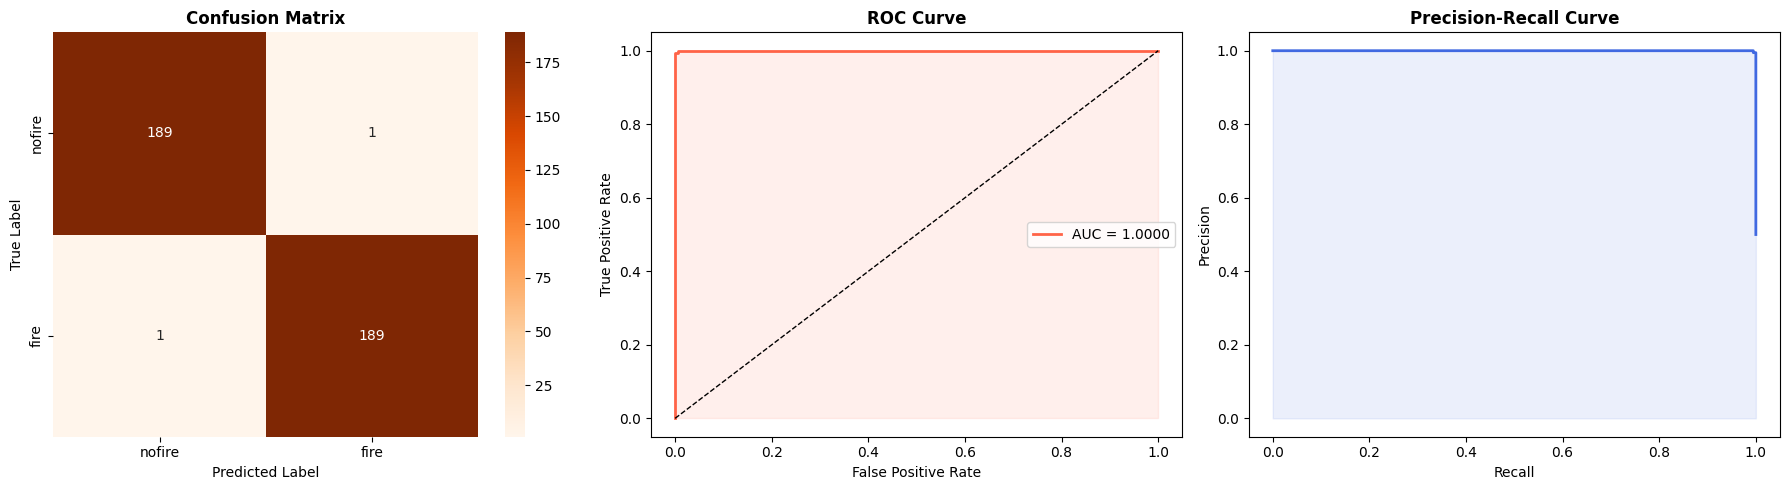

In [56]:
# ─── 15. Full Evaluation: Confusion Matrix, ROC, PR Curves ──────────────────

print('\n Classification Report:')
print(classification_report(
    tta_labels, tta_preds,
    target_names=[NORMAL_CLASS, FIRE_CLASS]
))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

cm = confusion_matrix(tta_labels, tta_preds)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Oranges',
    xticklabels=[NORMAL_CLASS, FIRE_CLASS],
    yticklabels=[NORMAL_CLASS, FIRE_CLASS],
    ax=axes[0]
)
axes[0].set_title('Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

fpr, tpr, _ = roc_curve(tta_labels, tta_probs)
axes[1].plot(fpr, tpr, color='tomato', lw=2, label=f'AUC = {tta_auc:.4f}')
axes[1].plot([0,1],[0,1], 'k--', lw=1)
axes[1].fill_between(fpr, tpr, alpha=0.1, color='tomato')
axes[1].set_xlabel('False Positive Rate'); axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontweight='bold')
axes[1].legend()

precision, recall, _ = precision_recall_curve(tta_labels, tta_probs)
axes[2].plot(recall, precision, color='royalblue', lw=2)
axes[2].fill_between(recall, precision, alpha=0.1, color='royalblue')
axes[2].set_xlabel('Recall'); axes[2].set_ylabel('Precision')
axes[2].set_title('Precision-Recall Curve', fontweight='bold')

plt.tight_layout()
plt.savefig('/kaggle/working/evaluation_plots.png', dpi=150)
plt.show()

   Loaded 380 images from /kaggle/working/Testing


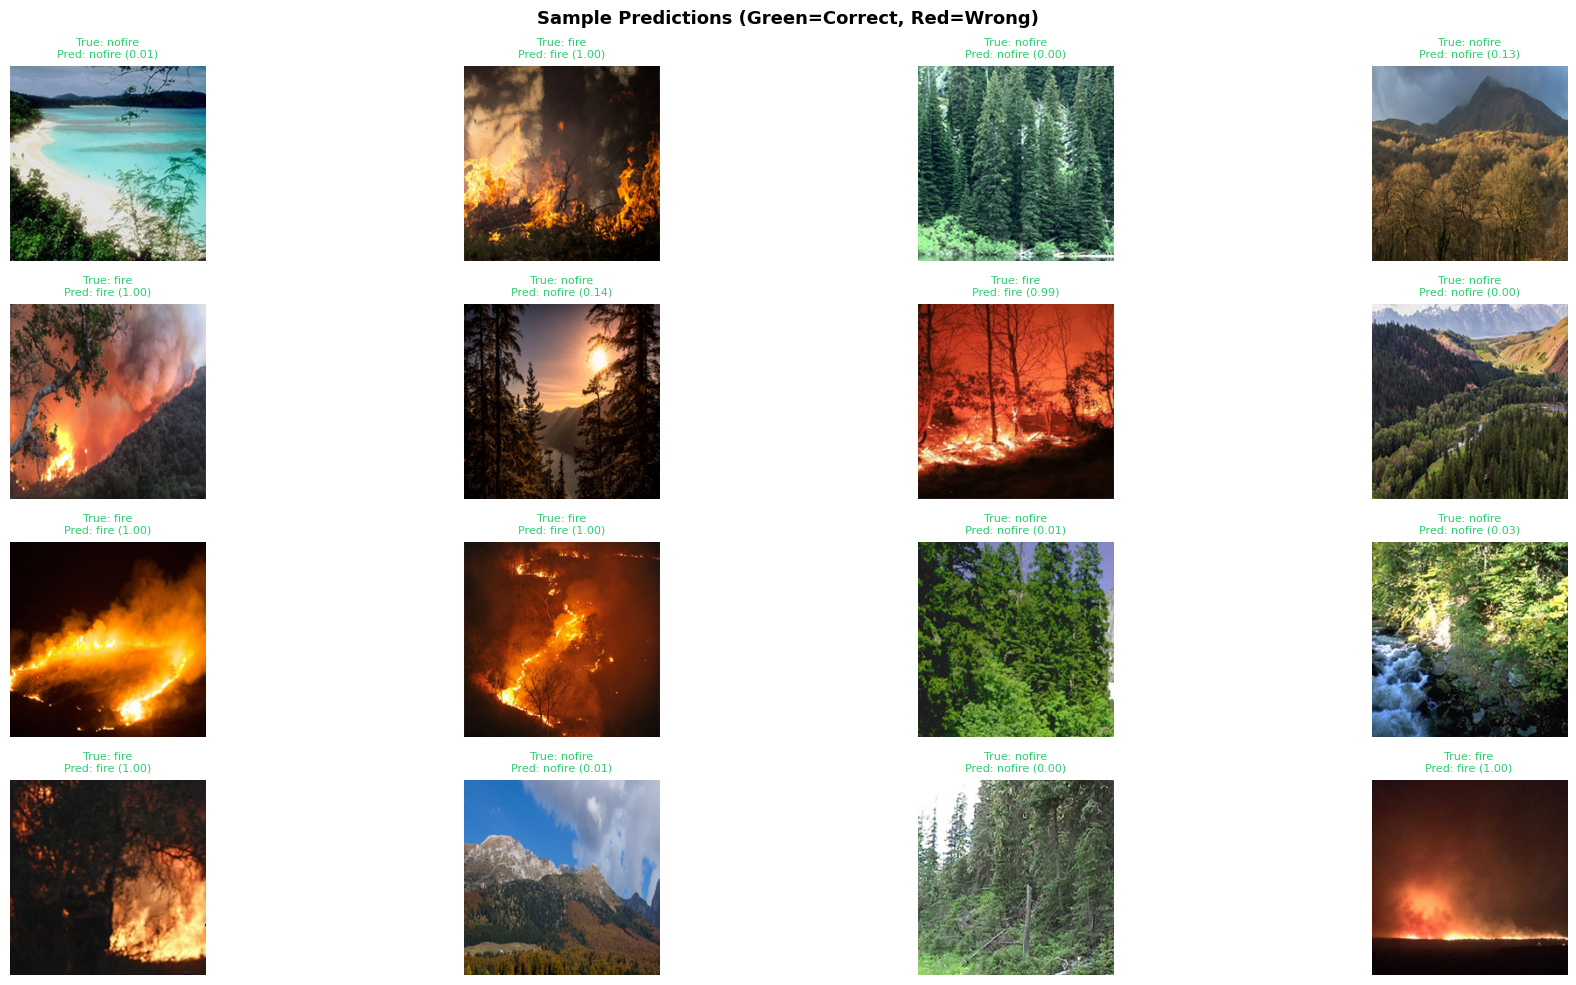

In [57]:
# ─── 16. Visualize Predictions on Sample Images ─────────────────────────────

@torch.no_grad()
def visualize_predictions(models_list, n=16):
    raw_ds = FireDataset(TEST_DIR, CLASS2IDX, transform=None)
    indices = random.sample(range(len(raw_ds)), min(n, len(raw_ds)))
    
    fig, axes = plt.subplots(4, n//4, figsize=(20, 10))
    axes = axes.flatten()
    
    for i, idx in enumerate(indices):
        img_pil, true_label = raw_ds[idx]
        
        preds = []
        for _ in range(3):
            aug = tta_transforms(img_pil).unsqueeze(0).to(DEVICE)
            for m in models_list:
                with autocast(enabled=CFG.MIXED_PRECISION):
                    preds.append(torch.sigmoid(m(aug)).item())
        prob = np.mean(preds)
        pred_label = int(prob > 0.5)
        
        correct = (pred_label == int(true_label.item()))
        color   = '#2ecc71' if correct else '#e74c3c'
        
        display_img = img_pil.resize((224, 224))
        axes[i].imshow(display_img)
        axes[i].set_title(
            f"True: {IDX2CLASS[int(true_label.item())]}\n"
            f"Pred: {IDX2CLASS[pred_label]} ({prob:.2f})",
            color=color, fontsize=8
        )
        axes[i].axis('off')
    
    plt.suptitle('Sample Predictions (Green=Correct, Red=Wrong)', fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/sample_predictions.png', dpi=150)
    plt.show()

visualize_predictions(models_list)

   Loaded 380 images from /kaggle/working/Testing
 Nombre d'images mal prédites : 1 / 380


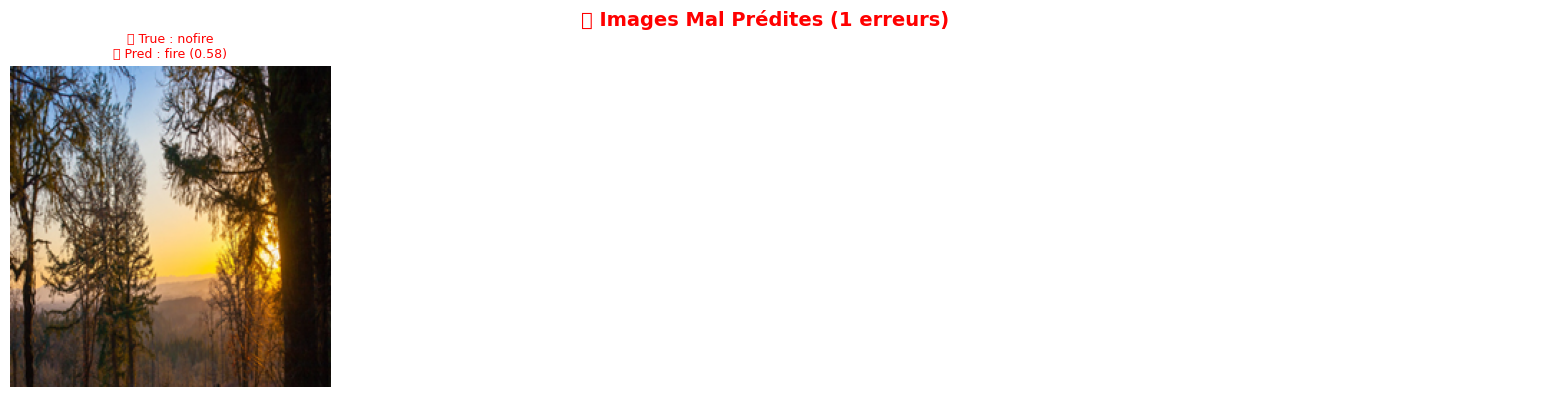

In [58]:
# ─── Afficher uniquement les images mal prédites ─────────────────────────────

@torch.no_grad()
def visualize_wrong_predictions(models_list):
    raw_ds = FireDataset(TEST_DIR, CLASS2IDX, transform=None)
    
    wrong_images = []
    
    for idx in range(len(raw_ds)):
        img_pil, true_label = raw_ds[idx]
        
        preds = []
        for _ in range(3):
            aug = tta_transforms(img_pil).unsqueeze(0).to(DEVICE)
            for m in models_list:
                with autocast(enabled=CFG.MIXED_PRECISION):
                    preds.append(torch.sigmoid(m(aug)).item())
        
        prob = np.mean(preds)
        pred_label = int(prob > 0.5)
        true = int(true_label.item())
        
        # Garder seulement les mauvaises prédictions
        if pred_label != true:
            wrong_images.append((img_pil, true, pred_label, prob))
    
    print(f' Nombre d\'images mal prédites : {len(wrong_images)} / {len(raw_ds)}')
    
    if len(wrong_images) == 0:
        print(' Aucune erreur ! Le modèle est parfait sur ce dataset.')
        return
    
    # Affichage
    cols = 4
    rows = math.ceil(len(wrong_images) / cols)
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 4, rows * 4))
    axes = np.array(axes).flatten()
    
    for i, (img_pil, true, pred, prob) in enumerate(wrong_images):
        axes[i].imshow(img_pil.resize((224, 224)))
        axes[i].set_title(
            f"✅ True : {IDX2CLASS[true]}\n❌ Pred : {IDX2CLASS[pred]} ({prob:.2f})",
            color='red', fontsize=9
        )
        axes[i].axis('off')
    
    # Cacher les cases vides
    for j in range(len(wrong_images), len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(f'❌ Images Mal Prédites ({len(wrong_images)} erreurs)', 
                 fontsize=14, fontweight='bold', color='red')
    plt.tight_layout()
    plt.savefig('/kaggle/working/wrong_predictions.png', dpi=150)
    plt.show()

visualize_wrong_predictions(models_list)

In [59]:
# ─── 17. GradCAM ─────────────────────────────────────────────────────────────
try:
    from pytorch_grad_cam import GradCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image
    from pytorch_grad_cam.utils.model_targets import BinaryClassifierOutputTarget

    target_layers = [model.backbone.features[-1]]

    raw_ds = FireDataset(TEST_DIR, CLASS2IDX, transform=None)
    fire_samples   = [(img, lbl) for img, lbl in [raw_ds[i] for i in range(len(raw_ds))] if lbl == 1][:4]
    normal_samples = [(img, lbl) for img, lbl in [raw_ds[i] for i in range(len(raw_ds))] if lbl == 0][:4]
    samples = fire_samples + normal_samples

    fig, axes = plt.subplots(2, 8, figsize=(24, 6))

    with GradCAM(model=model, target_layers=target_layers) as cam:
        for j, (img_pil, label) in enumerate(samples):
            img_tensor = val_transforms(img_pil).unsqueeze(0).to(DEVICE)
            img_np     = np.array(img_pil.resize((224, 224))) / 255.0

            targets   = [BinaryClassifierOutputTarget(int(label.item()))]
            grayscale = cam(input_tensor=img_tensor, targets=targets)[0]
            cam_img   = show_cam_on_image(img_np.astype(np.float32), grayscale, use_rgb=True)

            axes[0, j].imshow(img_np)
            axes[0, j].set_title(IDX2CLASS[int(label.item())], fontsize=9)
            axes[0, j].axis('off')

            axes[1, j].imshow(cam_img)
            axes[1, j].set_title('GradCAM', fontsize=9)
            axes[1, j].axis('off')

    plt.suptitle('GradCAM — Model Attention Maps', fontweight='bold')
    plt.tight_layout()
    plt.savefig('/kaggle/working/gradcam.png', dpi=150)
    plt.show()

except ImportError:
    print('  pytorch-grad-cam not installed. Run: !pip install grad-cam')
    print('   Skipping GradCAM visualization.')

  pytorch-grad-cam not installed. Run: !pip install grad-cam
   Skipping GradCAM visualization.


In [60]:
# ─── 18. Export Model ────────────────────────────────────────────────────────

checkpoint = {
    'model_state': model.state_dict(),
    'class2idx':   CLASS2IDX,
    'img_size':    CFG.IMG_SIZE,
    'val_auc':     tta_auc,
    'val_acc':     tta_acc,
}
torch.save(checkpoint, '/kaggle/working/fire_detector_final.pth')

try:
    model.eval()
    scripted = torch.jit.script(model)
    scripted.save('/kaggle/working/fire_detector_scripted.pt')
    print(' TorchScript model saved')
except Exception as e:
    print(f'  TorchScript export skipped: {e}')

print('\n Saved files:')
for f in Path('/kaggle/working').glob('*'):
    size_mb = f.stat().st_size / 1e6
    print(f'   {f.name:40s} {size_mb:.1f} MB')

 TorchScript model saved

 Saved files:
   best_model.pth                           84.3 MB
   fire_detector_scripted.pt                84.4 MB
   training_curves.png                      0.1 MB
   Testing                                  0.0 MB
   sample_predictions.png                   2.7 MB
   wrong_predictions.png                    0.4 MB
   best_model2.pth                          17.0 MB
   evaluation_plots.png                     0.1 MB
   .virtual_documents                       0.0 MB
   fire_detector_final.pth                  84.3 MB


In [61]:
# ─── 19. Inference Helper ────────────────────────────────────────────────────

def predict_single_image(img_path: str, threshold: float = 0.5) -> dict:
    model.eval()
    img = Image.open(img_path).convert('RGB')

    probs = []
    for _ in range(CFG.TTA_STEPS):
        t = tta_transforms(img).unsqueeze(0).to(DEVICE)
        with torch.no_grad(), autocast(enabled=CFG.MIXED_PRECISION):
            probs.append(torch.sigmoid(model(t)).item())

    fire_prob  = float(np.mean(probs))
    label      = FIRE_CLASS if fire_prob > threshold else NORMAL_CLASS
    confidence = fire_prob if label == FIRE_CLASS else (1 - fire_prob)

    return {'label': label, 'confidence': confidence, 'fire_probability': fire_prob}


sample_img, _ = test_ds.samples[0]
result = predict_single_image(str(sample_img))
print(f'Demo prediction:')
print(f'  Image     : {sample_img.name}')
print(f'  Label     : {result["label"]}')
print(f'  Confidence: {result["confidence"]:.2%}')
print(f'  Fire prob : {result["fire_probability"]:.4f}')

Demo prediction:
  Image     : fire_0335.jpg
  Label     : fire
  Confidence: 100.00%
  Fire prob : 1.0000


In [62]:
# ─── 20. Final Summary ──────────────────────────────────────────────────────

print('='*60)
print(' FIRE DETECTION MODEL — FINAL RESULTS')
print('='*60)
print(f'  Architecture  : EfficientNetV2-S + Custom Head')
if CFG.ENSEMBLE:
    print(f'  Ensemble with : MobileNetV3-Large')
print(f'  TTA Steps     : {CFG.TTA_STEPS}')
print(f'  Test Accuracy : {tta_acc:.4f} ({tta_acc*100:.2f}%)')
print(f'  Test ROC-AUC  : {tta_auc:.4f}')
print(f'  Test F1-Score : {tta_f1:.4f}')
print('='*60)
print('\n All done! Check /kaggle/working/ for saved models and plots.')

 FIRE DETECTION MODEL — FINAL RESULTS
  Architecture  : EfficientNetV2-S + Custom Head
  Ensemble with : MobileNetV3-Large
  TTA Steps     : 5
  Test Accuracy : 0.9947 (99.47%)
  Test ROC-AUC  : 1.0000
  Test F1-Score : 0.9947

 All done! Check /kaggle/working/ for saved models and plots.
